### STEP 0: Loading all packages needed for the project

In [11]:
# Basic packages
import sys
import os
import gc
import re
import io
import time
import requests
from datetime import datetime
import pathlib
from pathlib import Path
from glob import glob
from datetime import timedelta

# Data Analysis & Science
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
from bs4 import BeautifulSoup
import h5py 
from scipy import stats
from scipy.interpolate import RegularGridInterpolator

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline

# Specialized Tools
import earthaccess

# Add project root to path
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# Local scripts and EQLAT modules
from scripts.download_ERA_5 import download_era5_pv_pressure
from scripts.download_MERRA_2_new import download_merra2
from eqlat import (
    batch,
    roi_fast,
    interpolation,
    swoosh
)

### STEP 1.1: Load all necessary data directory 

In [2]:
# homepath for data
data_dir = os.path.join(
    pathlib.Path.home(),
    'Documents',
    'python',
    'eqlat_project',
    'data'
)
os.makedirs(data_dir, exist_ok=True)

# make directory for ozonesonde data 
o3sonde_dir = os.path.join(data_dir, 'ozonesonde')
os.makedirs(o3sonde_dir, exist_ok=True)

# make directory for era5 data 
era5_dir = os.path.join(data_dir, 'era5')
os.makedirs(era5_dir, exist_ok=True)

# make directory for merra2 data 
merra2_dir = os.path.join(data_dir, 'merra2')
os.makedirs(merra2_dir, exist_ok=True)

# directory for all figure
fig_dir = os.path.join(data_dir, 'figures')
os.makedirs(fig_dir, exist_ok=True)

### STEP 1.2: Load file path to ozonesonde data 

We’ll start with the ozonesonde data. Since we don’t want to load more reanalysis data than necessary — only the data corresponding to the period covered by the ozone probe data — we’ll begin with the ozonesonde data. First, we get an overview of how much data is available. For this project, we’ll start by looking only at ozone soundings from Boulder, Colorado. The following link leads to this data, which was provided by the GML's Department of Ozone and Water Vapor

In [3]:
def get_o3_file_paths(url):
    """
    Scrapes a webpage for links to ozone sonde data files (.dat).

    This function fetches the HTML content of the provided URL, parses it to find 
    all anchor tags, and filters for links ending in the '.dat' extension. 
    It converts relative paths into absolute URLs.

    Args:
        url (str): The destination URL containing the ozone data links.

    Returns:
        list: A list of strings, where each string is a full URL path 
            to a discovered '.dat' file. Returns an empty list if no 
            files are found or if the request fails.
    """
    # Ozone sondes data 
    # If error occures, reload the website and grab a new link ... don't know why
    tmp_url = url
    exts = ('.dat')

    response = requests.get(tmp_url)
    soup = BeautifulSoup(response.text, 'html.parser')

    # Get all links ending in our target extensions
    files = [a['href'] for a in soup.find_all('a', href=True) if a['href'].endswith(exts)]

    print(f"Found {len(files)} files.")

    return files


In [5]:
# Investigate the numbver of profiles for three different location in the USA
boulder_url = "https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Boulder,%20Colorado/Native%20Resolution%20(60s,%207s,%201s)/"
trinidad_url = "https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Trinidad%20Head,%20California/Native%20Resolution/"
huntsville_url = "https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Huntsville,%20Alabama/1%20Second%20Data%20Files/"

boulder_files = get_o3_file_paths(boulder_url)
trinidad_files = get_o3_file_paths(trinidad_url)
huntsville_files = get_o3_file_paths(huntsville_url)

Found 2226 files.
Found 1392 files.
Found 1035 files.


In [6]:
# we want to see if there are days where all three locations have a launch of an ozone sonde
def get_date(filename):
    # Searches for the YYYY_MM_DD pattern
    match = re.search(r'\d{4}_\d{2}_\d{2}', filename)
    return match.group(0) if match else None

# 1. Create dictionaries mapping dates to filenames
map1 = {get_date(f): f for f in boulder_files if get_date(f)}
map2 = {get_date(f): f for f in trinidad_files if get_date(f)}
map3 = {get_date(f): f for f in huntsville_files if get_date(f)}

# 2. Find common dates using Set intersection
common_dates = set(map1.keys()) & set(map2.keys()) & set(map3.keys())

# 3. Retrieve the full filenames
results = []
for date in common_dates:
    results.append({
        'date': date,
        'files': [map1[date], map2[date], map3[date]]
    })

print(f"Common dates found: {len(results)}")
for entry in results:
    print(f"Date: {entry['date']} -> Files: {entry['files']}")

Common dates found: 42
Date: 2006_08_17 -> Files: ['bu017_2006_08_17_fleout.dat', 'th526_2006_08_17_fleout.dat', 'hu398_2006_08_17_fleout.dat']
Date: 2006_08_28 -> Files: ['bu028_2006_08_28_fleout.dat', 'th537_2006_08_28_fleout.dat', 'hu409_2006_08_28_fleout.dat']
Date: 2006_08_20 -> Files: ['bu020_2006_08_20_fleout.dat', 'th529_2006_08_20_fleout.dat', 'hu401_2006_08_20_fleout.dat']
Date: 2009_10_31 -> Files: ['bu249_2009_10_31_fleout.dat', 'th726_2009_10_31_fleout.dat', 'hu593_2009_10_31_fleout.dat']
Date: 2006_08_27 -> Files: ['bu027_2006_08_27_fleout.dat', 'th536_2006_08_27_fleout.dat', 'hu408_2006_08_27_fleout.dat']
Date: 2006_03_03 -> Files: ['bl964_2006_03_03_fleout.dat', 'th476_2006_03_03_fleout.dat', 'hu354_2006_03_03_fleout.dat']
Date: 2006_08_10 -> Files: ['bu010_2006_08_10_fleout.dat', 'th520_2006_08_10_fleout.dat', 'hu391_2006_08_10_fleout.dat']
Date: 2008_07_05 -> Files: ['bu163_2008_07_05_fleout.dat', 'th654_2008_07_05_fleout.dat', 'hu516_2008_07_05_fleout.dat']
Date: 200

In [7]:
def read_noaa_O3_url(base_path, file_name, to_csv=True, o3sonde_dir='.'):
    """
    Downloads, parses, and cleans NOAA ozonesonde data from a specified URL.

    This function checks for locally cached versions of the data based on the date 
    string in the filename. If not found, it downloads the raw text, extracts 
    flight metadata (location, coordinates, flight number), flattens multi-index 
    headers, and converts GMT time strings into localized datetime objects.

    Args:
        base_path (str): The root URL or directory path where the raw file resides.
        file_name (str): The specific filename (e.g., 'bu_2023_05_12_18.l100'). 
            Expects underscores separating the date components at indices 1, 2, and 3.
        to_csv (bool): If True, saves the processed DataFrame to a CSV file. 
            Defaults to True.
        o3sonde_dir (str): The local directory path for checking existing files 
            and saving new output. Defaults to the current directory ('.').

    Returns:
        dict: A dictionary containing two keys:
            - 'date': (str) The ISO-formatted date string (YYYY-MM-DD).
            - 'data': (pd.DataFrame) The cleaned ozone profile data with 
              unified headers and 'DATETIME_GMT' column.
    """
    # PRE-COMPUTE FILENAME 
    # We need the flight number and location from the header to match your naming convention.
    # However, if you already know the file name pattern, we can check for it here.
    # If the local filename is predictable, we check BEFORE downloading.
    
    parts = file_name.split('_')
    date_str = "-".join(parts[1:4])
    
    # Check for any existing file matching this date and base name 
    # to avoid the download entirely.
    if to_csv:
        # We search for the date string in the directory to see if we've processed this day
        existing_files = [f for f in os.listdir(o3sonde_dir) if date_str in f and f.endswith('.csv')]
        if existing_files:
            print(f"Skipping: Data for {date_str} already exists locally ({existing_files[0]}).")
            # Optional: Load the existing file if you need to return the data anyway
            return {'date': date_str, 'data': pd.read_csv(os.path.join(o3sonde_dir, existing_files[0]))}

    # DOWNLOAD (Only happens if file doesn't exist)
    full_url = base_path + file_name
    response = requests.get(full_url)
    response.raise_for_status() 
    
    # PARSE METADATA
    lines = response.text.splitlines()
    data_start_idx = 0
    flight_nr, location, longitude, latitude = "UNK", "UNK", 0, 0

    for i, line in enumerate(lines):
        if 'Flight number' in line:
            flight_nr = line.split(' ')[-1]
        elif 'Location' in line:
            location = line.split(' ')[-2]
            print(location[:-1])
        elif 'Longitude' in line: 
            longitude = line.split(' ')[-1]
        elif 'Latitude' in line: 
            latitude = line.split(' ')[-1]
        elif "[min]" in line:
            data_start_idx = i - 2
            break
            
    # FAST PROCESSING
    df = pd.read_csv(
        full_url,
        skiprows=data_start_idx,
        header=[0, 1],
        sep=',',
        skipinitialspace=True,
        engine='python'
    )

    time_col = df['Time GMT'].iloc[:, 0]
    df['DATETIME GMT'] = pd.to_datetime(date_str + ' ' + time_col)
    df['launch_lat'] = latitude
    df['launch_lon'] = longitude

    new_names = []
    for i in df.columns:
        new_names.append(i[0] + ' ' + i[1])

    df.columns = new_names
    df  = df.replace(99999, np.nan)

    # SAVE
    if to_csv:
        out_name = f'ozonesonde_{flight_nr}_{location[:-1]}_{"".join(parts[1:4])}.csv'
        df.to_csv(os.path.join(o3sonde_dir, out_name), index=False)
        print(f"Successfully processed and saved: {out_name}")

    return {'date': date_str, 'data': df}

In [9]:
def get_reanalysis_for_O3sonde(ozone_dic, 
                               era5_out_dir,
                               merra2_out_dir,
                               use_sonde_time=False):
    """
    Downloads ERA5 and MERRA-2 reanalysis data covering the duration of an ozone sonde flight.

    The function extracts flight timing from the input, determines the 
    required hourly window for ERA5, and downloads a two-day window for MERRA-2 
    to ensure temporal coverage for lower-resolution datasets.

    Parameters
    ----------
    ozone_dic : dict
        A dictionary containing ozone sonde metadata and data. 
        Must include:
        - 'date': str in 'YYYY-MM-DD' format.
        - 'data': pd.DataFrame containing a 'DATETIME GMT ' column with 
          pandas-compatible timestamps.
    era5_out_dir : str or Path
        Directory path where the downloaded ERA5 NetCDF/GRIB files will be stored.
    merra2_out_dir : str or Path
        Directory path where the downloaded MERRA-2 subset files will be stored.
    use_sonde_time : boolean 
        use the time from the ozone sonde to limit the import 
    Returns
    -------
    None
        The function triggers external download processes and saves files to disk.

    Notes
    -----
    - ERA5 data is requested specifically for the hours overlapping the flight 
      using `download_era5_pv_pressure`.
    - MERRA-2 data is downloaded for the flight day and the following day to 
      account for coarser temporal resolution or cross-day flight legs.
    """

    year, month, day = ozone_dic['date'].split('-')
    
    if use_sonde_time==True:
      

      start = ozone_dic['data']['DATETIME GMT '].min()
      end = ozone_dic['data']['DATETIME GMT '].max()

      # get the full hour before launch until end of launch
      start_full_hour = start.floor('h')
      end_full_hour = end.ceil('h')

      # Generate the range of hours
      hour_range = pd.date_range(start=start_full_hour, end=end_full_hour, freq='h')
      # Format as 'HH:MM' and convert to a list
      hours_list = hour_range.strftime("%H:%M").tolist()
    
    else: 
      hours_list = ["00:00", "01:00", "02:00", "03:00", "04:00", "05:00", "06:00",
                    "07:00", "08:00", "09:00", "10:00", "11:00", "12:00", "13:00",
                    "14:00", "15:00", "16:00", "17:00", "18:00", "19:00", "20:00",
                    "21:00", "22:00", "23:00"]

    download_era5_pv_pressure(int(year),
                              int(month),
                              int(day),
                              outdir=era5_out_dir,
                              hours = hours_list)
    
    # as the the time resolution is coarser, take the day after the flight as well
    download_merra2(int(year),
                    int(month),
                    int(day),
                    hours_utc=None,
                    outdir = merra2_out_dir)
    
    download_merra2(int(year),
                    int(month),
                    int(day),
                    hours_utc=None,
                    outdir = merra2_out_dir)

### STEP 2: Equivalent Latitude vertical profiles from different methods

In [10]:
# Load SWOOSH data. 
# This data mus be manually downloaded from thre NOA website
File = '/Users/jesswein/Documents/python/eqlat_project/data/swoosh/swoosh-v02.72-198401-202601-lattheta-5deg-L33.nc'

swoosh_ds = xr.open_dataset(File)

/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'aceh2on' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'aceh2oneq' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'acen2on' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'acen2oneq' has non-conforming 'missing_value' np.float32(na

In [12]:
def get_elat_sonde(date_str, location, method='piecewise'): 
    # 1. Convert string input to a Datetime object for safe math
    current_date = pd.to_datetime(date_str)
    next_date = current_date + pd.Timedelta(days=1)
    
    # 2. Format back to strings for glob (adjust format '%Y%m%d' as needed)
    d1 = current_date.strftime('%Y%m%d')
    d2 = next_date.strftime('%Y%m%d')

    try: 
        # Use the formatted strings in your search patterns
        sonde_path = glob(f"{o3sonde_dir}/*{location}_{d1}.csv")[0]
        era5_path = glob(f"{era5_dir}/*{method}_{d1}.nc")[0]
        merra2_path_1 = glob(f"{merra2_dir}/*{method}_{d1}.nc")[0]
        merra2_path_2 = glob(f"{merra2_dir}/*{method}_{d2}.nc")[0]

        # Load Ozonesonde
        tmp_ozonesonde = pd.read_csv(sonde_path)
        tmp_ozonesonde['DATETIME GMT '] = pd.to_datetime(tmp_ozonesonde['DATETIME GMT '])
        
        # Filter for ascending data
        tmp_ozone = tmp_ozonesonde[tmp_ozonesonde['Rise Rate [m/s]'] >= 0].copy()

        # Load Reanalysis
        era5_ds = xr.open_dataset(era5_path)
        
        # Open both MERRA-2 files and combine them along the time dimension
        merra2_ds = xr.open_mfdataset([merra2_path_1, merra2_path_2], 
                                      combine='nested', 
                                      concat_dim='time')

        #return tmp_ozone, era5_ds, merra2_ds
        
    except IndexError:
        print(f"Missing files for {location} on {d1} or {d2}")
        return None, None, None
    except Exception as e:
        print(f"Error: {e}")
        return None, None, None
    
    target_time = xr.DataArray(tmp_ozone['DATETIME GMT '], dims='z')
    target_theta = xr.DataArray(tmp_ozone['Theta [K]'], dims='z')
    try:
        target_lat = xr.DataArray(tmp_ozone['GPS lat [deg]'], dims='z')
        target_lon = xr.DataArray(tmp_ozone['GPS lon [deg]'], dims='z')
    except:
        target_lat = xr.DataArray(tmp_ozone['launch_lat '], dims='z')
        target_lon = xr.DataArray(tmp_ozone['launch_lon '], dims='z')

    profile_eq_lat_era5 = era5_ds["eqlat"].interp(
        valid_time=target_time,
        theta=target_theta,
        latitude=target_lat,
        longitude=target_lon  % 360,
        method='linear'
    )

    profile_eq_lat_merra2 = merra2_ds["eqlat"].interp(
        time=target_time,
        theta=target_theta,
        lat=target_lat,
        lon=target_lon ,
        method='linear'
    )

    profile_eq_lat_swoosh, field = swoosh.equivalent_latitude_swoosh_new(swoosh_ds, 
                                                                     tmp_ozone['Theta [K]'].values,
                                                                     tmp_ozone['O3 Mr [ppmv]'].values,
                                                                     tmp_ozonesonde['DATETIME GMT '].iloc[0],
                                                                     o3_varname = "combinedo3qeq",
                                                                     monotone_enforce=0.05
                                                                     )
    
    return {'Ozonesonde': tmp_ozone,
            'ERA5_eqlat' : profile_eq_lat_era5,
            'MERRA2_eqlat': profile_eq_lat_merra2,
            'SWOOSH_eqlat': profile_eq_lat_swoosh,
            'SWOOSH_filed': field}


In [13]:
def plot_eqlat_comparison(eqlat_data, date, set_ylim=(300, 900)):
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Background Ozone Field
    # Using 'extend' captures values outside vmin/vmax for a cleaner look
    contour_plot = eqlat_data['SWOOSH_filed'].plot.contourf(
        ax=ax,
        levels=50, 
        cmap='viridis', 
        vmin=0, 
        vmax=8,
        extend='both',
        cbar_kwargs={'label': 'Ozone Mixing Ratio [ppmv]'}
    )

    # 2. Trajectory Lines
    # Plotting geographic path (white for contrast against dark viridis)
    try:
        ax.plot(eqlat_data['Ozonesonde']['launch_lat '], 
                eqlat_data['Ozonesonde']['Theta [K]'], 
                color='white', 
                #marker= '.',
                lw=2, 
                label='Geo Lat Path')
    except:
        ax.plot(eqlat_data['Ozonesonde']['GPS lat [deg]'], 
                eqlat_data['Ozonesonde']['Theta [K]'], 
                color='white', 
                #marker= '.',
                lw=2, 
                label='Geo Lat Path')

    # Equivalent Latitudes
    ax.plot(eqlat_data['SWOOSH_eqlat'], 
            eqlat_data['Ozonesonde']['Theta [K]'], 
            color='black', 
            #marker= '.',
            lw=1.5, 
            label='SWOOSH EqLat')
    
    ax.plot(eqlat_data['ERA5_eqlat'].values, 
            eqlat_data['ERA5_eqlat'].theta.values, 
            color='lime', 
            marker= '.', 
            markersize=0.75,
            lw=0, 
            label='ERA5 EqLat') # Lime green pops better
    
    ax.plot(eqlat_data['MERRA2_eqlat'].values, 
            eqlat_data['MERRA2_eqlat'].theta.values, 
            color='red', 
            marker= '.', 
            markersize=0.75,
            lw=0, 
            label='MERRA2 EqLat')

    # 3. Aesthetics and Limits
    ax.set_title(f'Ozone Distribution vs. Potential Temperature ({date})', fontsize=14)
    ax.set_xlabel('Latitude / Equivalent Latitude [deg]', fontsize=12)
    ax.set_ylabel(r'Potential Temperature $\theta$ [K]', fontsize=12)
    
    ax.set_xlim(0, 85) 
    ax.set_ylim(set_ylim)
    
    # Grid and Legend
    ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.8)

    plt.tight_layout()
    plt.show()

### STEP 3: Equivalent Latitude profiles - same day but different stations

Read files for 2016-06-06

In [14]:
target_date = '2006_03_03'

# Grabs the file list if the date matches
files = [item['files'] for item in results if item['date'] == target_date][0]

# Output will be: [['bu029_2006_08_29_fleout.dat', 'th538_2006_08_29_fleout.dat', ...]]
# To get just the inner list:
if files:
    print(files)

['bl964_2006_03_03_fleout.dat', 'th476_2006_03_03_fleout.dat', 'hu354_2006_03_03_fleout.dat']


In [15]:
files

['bl964_2006_03_03_fleout.dat',
 'th476_2006_03_03_fleout.dat',
 'hu354_2006_03_03_fleout.dat']

In [16]:
read_noaa_O3_url(boulder_url, files[0], o3sonde_dir=o3sonde_dir)
read_noaa_O3_url(trinidad_url, files[1], o3sonde_dir=o3sonde_dir)
read_noaa_O3_url(huntsville_url, files[2], o3sonde_dir=o3sonde_dir)

Boulder
Successfully processed and saved: ozonesonde_BL964_Boulder_20060303.csv
Head
Successfully processed and saved: ozonesonde_TH476_Head_20060303.csv
Huntsville
Successfully processed and saved: ozonesonde_HU354_Huntsville_20060303.csv


{'date': '2006-03-03',
 'data':       Time [min]  Time Sec [sec] Time GMT [hh:mm:ss GMT]  Press [hPa]  \
 0           0.00             0.0                19:07:32       998.33   
 1           0.02             1.2                19:07:33       997.71   
 2           0.04             2.4                19:07:34       997.21   
 3           0.06             3.6                19:07:35       996.57   
 4           0.08             4.8                19:07:36       995.47   
 ...          ...             ...                     ...          ...   
 5671      123.91          7434.6                21:11:26       590.88   
 5672      123.93          7435.8                21:11:27       591.82   
 5673      123.95          7437.0                21:11:29       592.65   
 5674      123.97          7438.2                21:11:30       593.63   
 5675      123.99          7439.4                21:11:31       594.49   
 
       Praw [hPa]  Alt [km]  Tcorr [deg C]  Temp [deg C]  Theta [K]  RH [%]  \


In [ ]:
download_era5_pv_pressure(2006,
                          3,
                          3,
                          outdir=era5_dir,
                          hours = ["00:00", "01:00", "02:00", "03:00", "04:00", "05:00", "06:00",
                                    "07:00", "08:00", "09:00", "10:00", "11:00", "12:00", "13:00",
                                    "14:00", "15:00", "16:00", "17:00", "18:00", "19:00", "20:00",
                                    "21:00", "22:00", "23:00"])

  Levels: [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, 150, 175, 200, 225, 250, 300, 325, 350] hPa


2026-04-27 16:32:49,365 INFO Request ID is 258d19fe-bfe9-4f40-88c2-eae1f9d7aaae
2026-04-27 16:32:49,528 INFO status has been updated to accepted
2026-04-27 16:33:11,319 INFO status has been updated to running
2026-04-27 16:39:11,253 INFO status has been updated to successful
                                                                                         

  Done: /Users/jesswein/Documents/python/eqlat_project/data/era5/era5_pv_pressure_20060303.nc


'/Users/jesswein/Documents/python/eqlat_project/data/era5/era5_pv_pressure_20060303.nc'

In [18]:
download_merra2(2006,
                3,
                3,
                outdir = merra2_dir)

download_merra2(2006,
                3,
                4,
                outdir = merra2_dir)

  Collection : M2I3NPASM
  Variables  : ['EPV', 'T']
  Time steps : all
  URL        : https://goldsmr5.gesdisc.eosdis.nasa.gov/opendap/MERRA2/M2I3NPASM.5.12.4/2006/03/MERRA2_300.inst3_3d_asm_Np.20060303.nc4.nc4?time[0:1:7],lev[0:1:41],lat[0:1:360],lon[0:1:575],EPV[0:1:7][0:1:41][0:1:360][0:1:575],T[0:1:7][0:1:41][0:1:360][0:1:575]
  Output     : /Users/jesswein/Documents/python/eqlat_project/data/merra2/merra2_EPV_T_20060303_t00-07.nc4
  Done  (278.8 MB)
  Collection : M2I3NPASM
  Variables  : ['EPV', 'T']
  Time steps : all
  URL        : https://goldsmr5.gesdisc.eosdis.nasa.gov/opendap/MERRA2/M2I3NPASM.5.12.4/2006/03/MERRA2_300.inst3_3d_asm_Np.20060304.nc4.nc4?time[0:1:7],lev[0:1:41],lat[0:1:360],lon[0:1:575],EPV[0:1:7][0:1:41][0:1:360][0:1:575],T[0:1:7][0:1:41][0:1:360][0:1:575]
  Output     : /Users/jesswein/Documents/python/eqlat_project/data/merra2/merra2_EPV_T_20060304_t00-07.nc4
  Done  (278.0 MB)


'/Users/jesswein/Documents/python/eqlat_project/data/merra2/merra2_EPV_T_20060304_t00-07.nc4'

In [19]:
def process_fields(fields, both_methods=True, version='ERA5'):
    # Potential temperature levels in Kelvin
    theta_levels = [300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 
                    425, 450, 475, 500, 550, 600, 650, 700, 750, 800, 900, 1000]
    
    if both_methods == True:
        methods = ['piecewise', 'roi']
    else: 
        methods = ['piecewise']
    
    if version == 'ERA5':
        name_add = 'era5'
        tmp_dir = era5_dir
    elif version == 'MERRA2':
        name_add = 'merra2'
        tmp_dir = merra2_dir

    for field in fields:
        # Better date parsing: assumes filename ends in YYYYMMDD.nc or similar
        # Extracting the basename ensures directory paths don't interfere
        base_name = os.path.basename(field)
        if version == 'ERA5':
            date_str = base_name.split('_')[-1].replace('.nc', '')
        elif version == 'MERRA2':
            date_str = base_name.split('_')[-2]

        for m in methods:
            filename = f"{name_add}_eqlat_{m}_{date_str}.nc"
            filepath = os.path.join(tmp_dir, filename)

            # Skip if already processed to save significant computation time
            if os.path.exists(filepath):
                print(f"Skipping: {filename} already exists.")
                continue

            print(f"Processing {m} for {date_str}...")
            
            try:
                tmp_field = batch.process_pressure_netcdf(field, 
                                                          theta_levels,
                                                          method=m)
                
                # Use 'w' mode to ensure a fresh file
                tmp_field.to_netcdf(filepath)
                
                # Explicitly close or delete to free up memory
                tmp_field.close() 
            except Exception as e:
                print(f"Error processing {field} with method {m}: {e}")

Create Equivalent Latitude fields, but only for the piecewise-constant method.

In [20]:
process_fields(glob(era5_dir+f'/*pv_pressure_20060303.nc'),both_methods=False)

Processing piecewise for 20060303...
Pressure levels in file: 1.0–350.0 hPa  (19 levels)
Theta levels requested:  [300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0, 425.0, 450.0, 475.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 900.0, 1000.0]
Grid: 721 lat × 1440 lon,  24 time steps
Total slices: 24 × 23 = 552


interp+eqlat/piecewise: 100%|██████████| 552/552 [03:03<00:00,  3.00slice/s]


In [23]:
process_fields(glob(merra2_dir+f'/*EPV_T_200603*'),both_methods=False, version='MERRA2')

Processing piecewise for 20060304...
Pressure levels in file: 0.1–1000.0 hPa  (42 levels)
Theta levels requested:  [300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0, 425.0, 450.0, 475.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 900.0, 1000.0]
Grid: 361 lat × 576 lon,  8 time steps
Total slices: 8 × 23 = 184


interp+eqlat/piecewise: 100%|██████████| 184/184 [00:16<00:00, 11.50slice/s]


Processing piecewise for 20060303...
Pressure levels in file: 0.1–1000.0 hPa  (42 levels)
Theta levels requested:  [300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0, 425.0, 450.0, 475.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 900.0, 1000.0]
Grid: 361 lat × 576 lon,  8 time steps
Total slices: 8 × 23 = 184


interp+eqlat/piecewise: 100%|██████████| 184/184 [00:16<00:00, 11.34slice/s]


In [24]:
eqlat_boulder_20060303 = get_elat_sonde('20060303', 'Boulder')
eqlat_Huntsville_20060303 = get_elat_sonde('20060303', 'Huntsville')
eqlat_Head_20060303 = get_elat_sonde('20060303', 'Head')

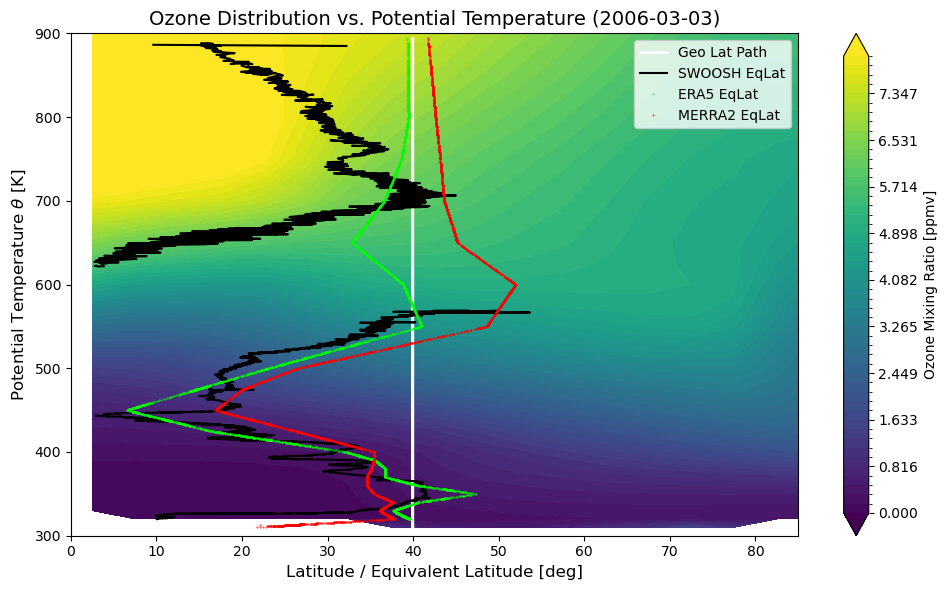

In [25]:
plot_eqlat_comparison(eqlat_boulder_20060303, '2006-03-03', set_ylim=(300, 900))

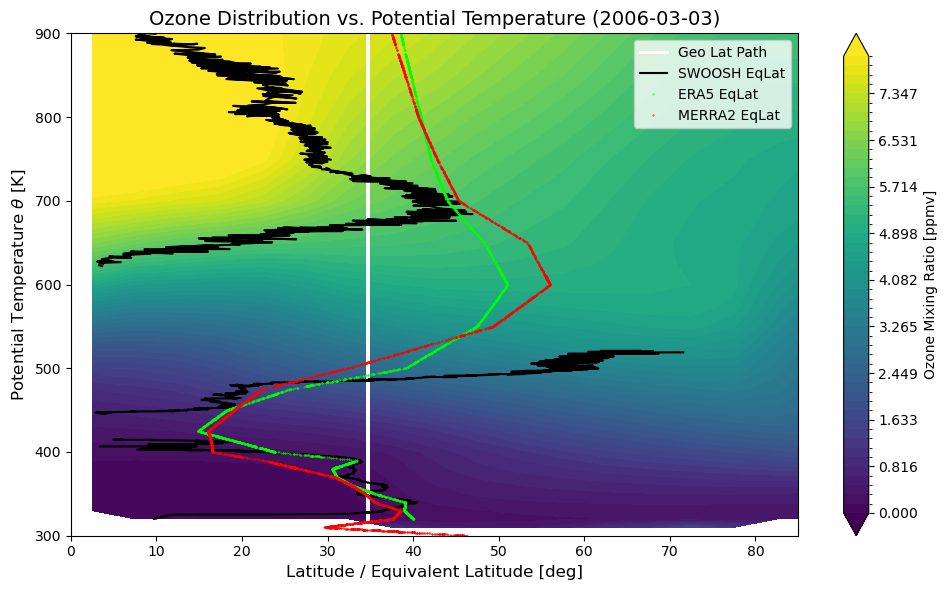

In [26]:
plot_eqlat_comparison(eqlat_Huntsville_20060303, '2006-03-03')

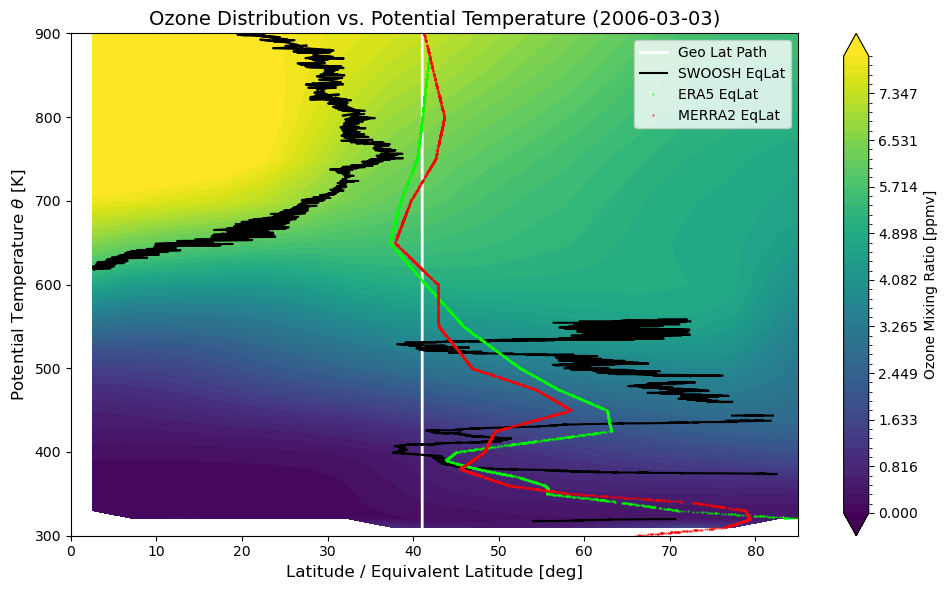

In [27]:
plot_eqlat_comparison(eqlat_Head_20060303, '2006-03-03')

In [20]:
# eqlat_boulder_20160606 = get_elat_sonde('20160606', 'Boulder')
# eqlat_Huntsville_20160606 = get_elat_sonde('20160606', 'Huntsville')
# eqlat_Head_20160606 = get_elat_sonde('20160606', 'Head')

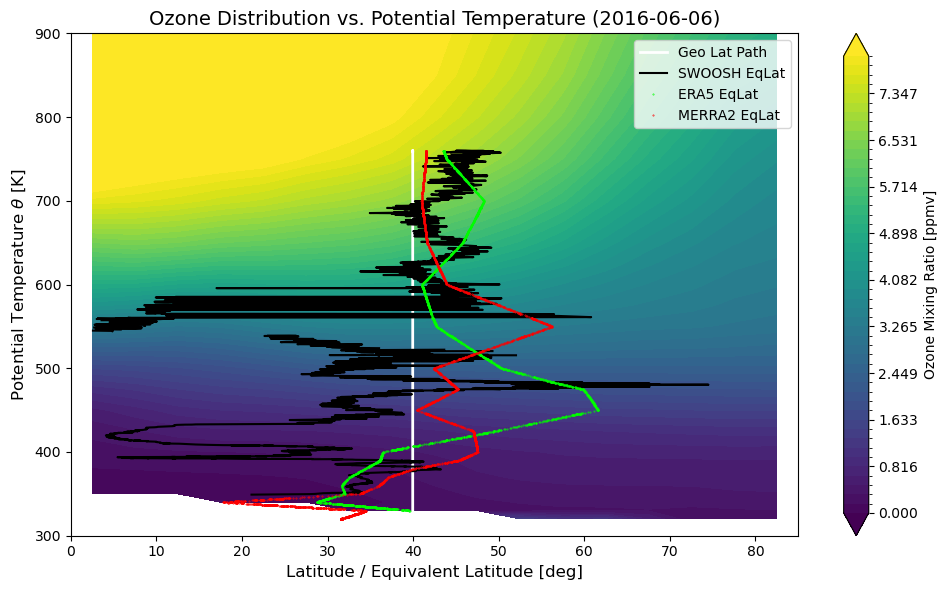

In [115]:
# plot_eqlat_comparison(eqlat_boulder_20160606, '2016-06-06')

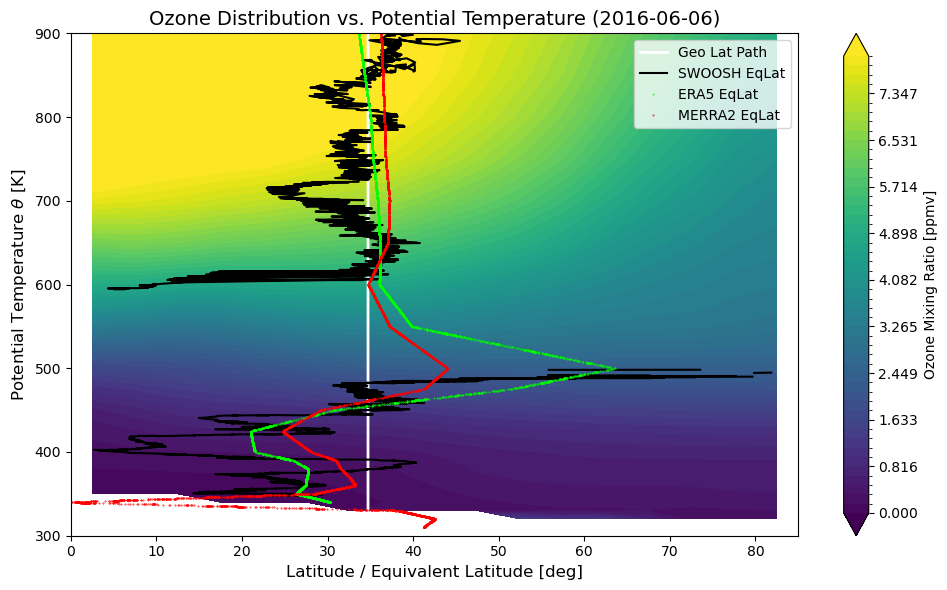

In [116]:
# plot_eqlat_comparison(eqlat_Huntsville_20160606, '2016-06-06')

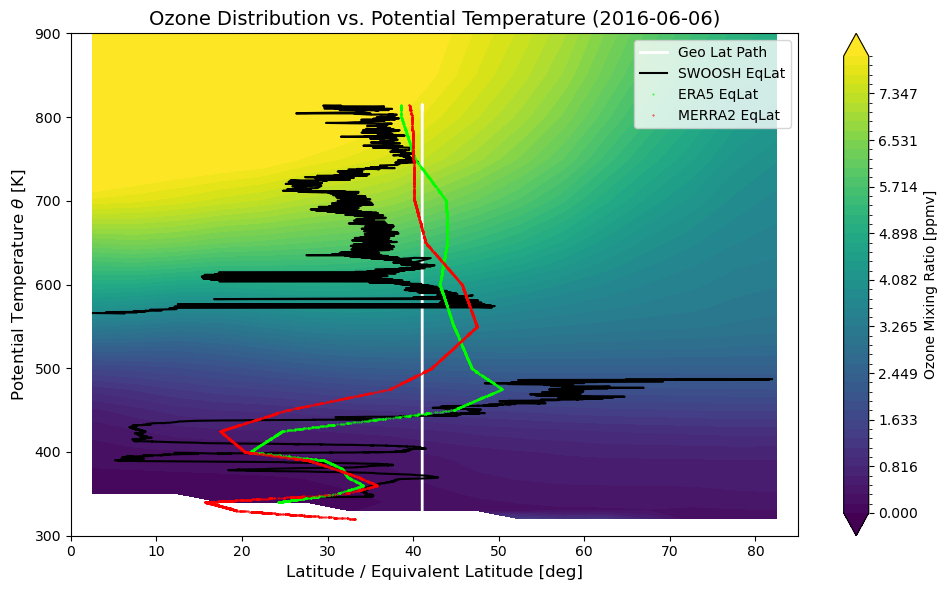

In [117]:
# plot_eqlat_comparison(eqlat_Head_20160606, '2016-06-06')

In [29]:
def bias_noise(eqlat_data):
    df = pd.DataFrame({
    'vert': eqlat_data['Ozonesonde']['Theta [K]'].values,    # Höhe oder Potentielle Temperatur
    'eqlat_swoosh': eqlat_data['SWOOSH_eqlat'], # Die aus Ozon abgeleitete EqLat
    'eqlat_era5': eqlat_data['ERA5_eqlat'].values,   # Dynamische EqLat von ERA5
    'eqlat_merra2': eqlat_data['MERRA2_eqlat'].values  # Dynamische EqLat von MERRA-2
    })

    # 1. Differenzen berechnen (Mismatch)
    df['diff_era5'] = df['eqlat_era5'] - df['eqlat_swoosh']
    df['diff_merra2'] = df['eqlat_merra2'] - df['eqlat_swoosh']

    # 2. Gruppierung nach Höhe (Bins erstellen, falls viele Sonden vorliegen)
    # Falls du nur eine Sonde hast, kannst du direkt plotten. 
    # Bei vielen Sonden nutzen wir Bins für das Profil.
    bin_size = 5 # z.B. alle 2 km oder 10 Kelvin
    df['height_bin'] = (df['vert'] / bin_size).round() * bin_size

    # Statistiken pro Höhenstufe berechnen
    profile_stats = df.groupby('height_bin').agg({
        'diff_era5': ['mean', 'std'],
        'diff_merra2': ['mean', 'std']
    }).reset_index()

    # 3. Visualisierung
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # Linker Plot: Mittlerer Bias (Systematische Abweichung)
    ax[0].plot(profile_stats[('diff_era5', 'mean')], profile_stats['height_bin'], 
            label='ERA5 Bias', color='blue', lw=2)
    ax[0].plot(profile_stats[('diff_merra2', 'mean')], profile_stats['height_bin'], 
            label='MERRA-2 Bias', color='green', lw=2)
    ax[0].axvline(0, color='black', linestyle='--', alpha=0.5)
    ax[0].set_title('Systematic Bias\n(Relativ to SWOOSH O3-EqLat)')
    ax[0].set_xlabel('Differences in Degree [°]')
    ax[0].set_ylabel('Theta [K]')
    ax[0].legend()

    # Rechter Plot: Standardabweichung (Rauschen/Präzision)
    ax[1].plot(profile_stats[('diff_era5', 'std')], profile_stats['height_bin'], 
            label='ERA5 StdDev', color='blue', linestyle='--')
    ax[1].plot(profile_stats[('diff_merra2', 'std')], profile_stats['height_bin'], 
            label='MERRA-2 StdDev', color='green', linestyle='--')
    ax[1].set_title('Variability (Noise)\n(How consistent is the Dynamic?)')
    ax[1].set_xlabel('Standard Deviation [°]')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

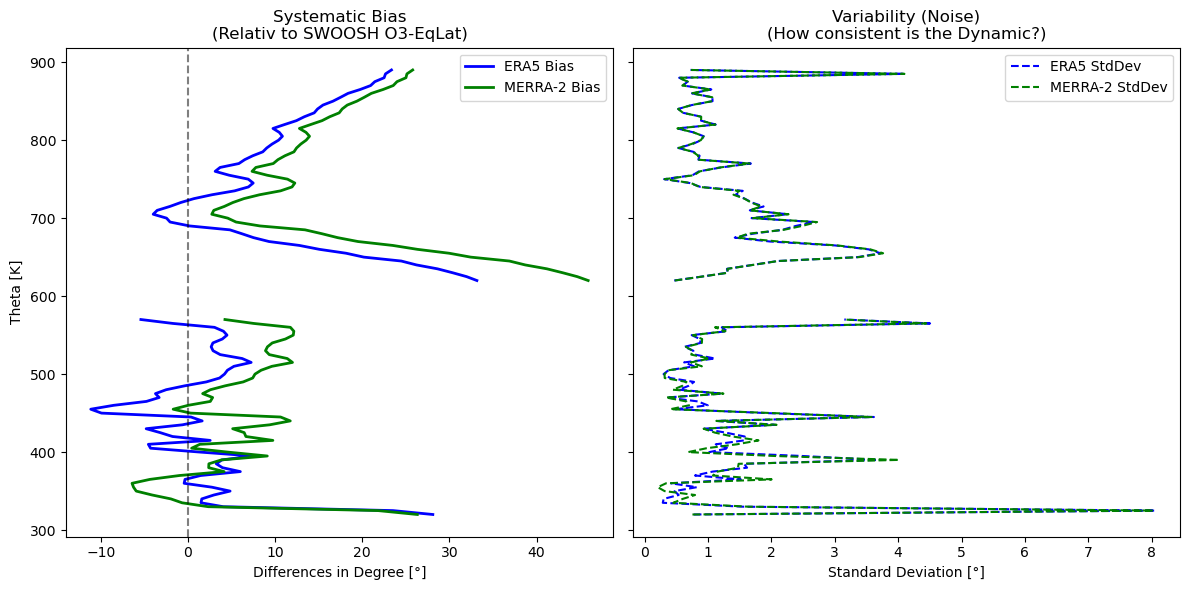

In [30]:
bias_noise(eqlat_boulder_20060303)

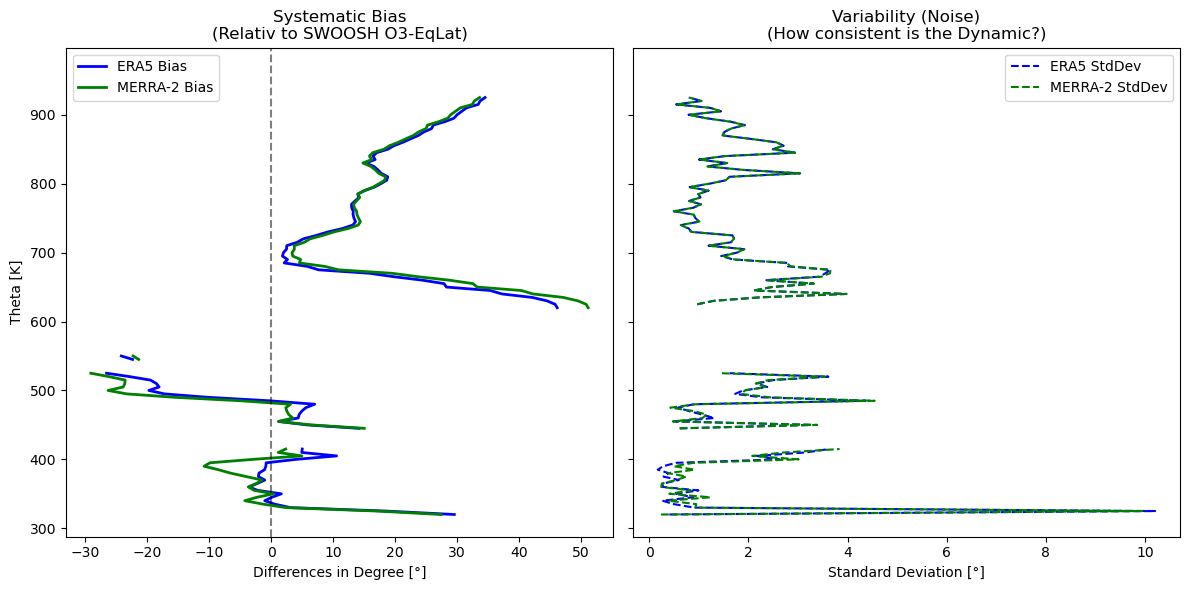

In [31]:
bias_noise(eqlat_Huntsville_20060303)

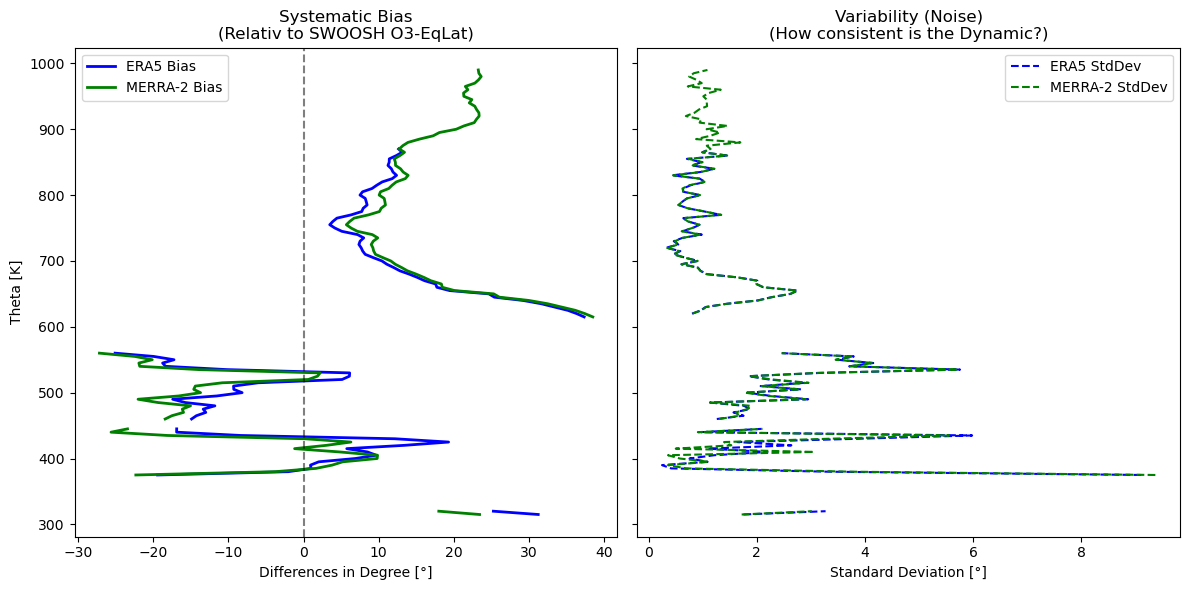

In [32]:
bias_noise(eqlat_Head_20060303)